<a href="https://colab.research.google.com/github/asmit-ayank/UCS411/blob/main/Emotion_Detection_from_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion Detection from Text
Emotion is one of the basic instincts of a human being. Emotion detection plays a vital role in the field of textual analysis. At present, people’s expressions and emotional states have turned into the leading topic for research works. Emotion Detection and Recognition from texts are recent fields of research that are closely related to Emotion Analysis. Emotion Analysis aims at detecting and recognizing feelings through the expressions from sentences, such as *anger*, *surprise*, *joy*, *fear*, *sadness*, *love* etc.

**Course No:** UCS-411

**Course Name:** Artificial Intelligence Lab



**Team Members**

*   102497002 - Asmit Ayank
*   102497008 - Lucky Singh




In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Text Libraries
import nltk
import string
import re

# Feature Extraction Libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split

# Classifier Model libraries
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree
# from sklearn.pipeline import Pipeline

# Performance Matrix libraries
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# other
import warnings
warnings.filterwarnings("ignore")

# Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Dataset

In [2]:
# Ensure df is not a string before attempting to read the CSV
#del df # Delete existing df if it's a string

# Now read the CSV
df = pd.read_csv("/content/drive/MyDrive/Emotion_Detector/text_emotions.csv")

In [3]:
print('Dataset size:',df.shape)
print('Columns are:',df.columns)
Y = df['sentiment']

Dataset size: (20000, 2)
Columns are: Index(['content', 'sentiment'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    20000 non-null  object
 1   sentiment  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


## Dataset Emotion Analysis

<Axes: xlabel='sentiment', ylabel='count'>

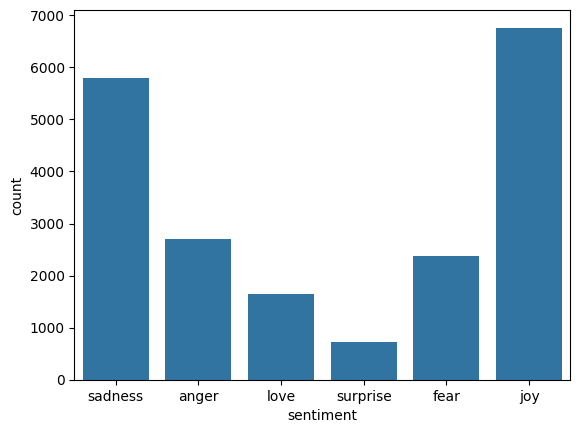

In [5]:
sns.countplot(x = 'sentiment', data = df)

# 2. Pre-processing text data
    1. Remove punctuations
    2. Tokenization - Converting a sentence into list of words
    3. Remove stopwords
    4. Lammetization/stemming - Tranforming any form of a word to its root word

## 2.1 Remove Punctuations

In [7]:
emojis = pd.read_csv('/content/drive/MyDrive/Emotion_Detector/emojis.txt',sep=',',header=None)
emojis_dict = {i:j for i,j in zip(emojis[0],emojis[1])}
pattern = '|'.join(sorted(re.escape(k) for k in emojis_dict))

def replace_emojis(text):
    text = re.sub(pattern,lambda m: emojis_dict.get(m.group(0)), text, flags=re.IGNORECASE)
    return text

def remove_punct(text):
    text = replace_emojis(text)
    text  = "".join([char for char in text if char not in string.punctuation])
    text = re.sub('[0-9]+', '', text)
    return text

df['Tweet_punct'] = df['content'].apply(lambda x: remove_punct(x))
df.head(10)

,content,sentiment,Tweet_punct
0,i didnt feel humiliated,sadness,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,anger,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,surprise,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,fear,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,joy,i have been with petronas for years i feel tha...
9,i feel romantic too,love,i feel romantic too


## 2.2 Tokenization

In [8]:
def tokenization(text):
    text = text.lower()
    text = re.split('\W+', text)

    return text

df['Tweet_tokenized'] = df['Tweet_punct'].apply(lambda x: tokenization(x.lower()))
df.head(10)

,content,sentiment,Tweet_punct,Tweet_tokenized
0,i didnt feel humiliated,sadness,i didnt feel humiliated,"[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,anger,i am feeling grouchy,"[i, am, feeling, grouchy]"
5,ive been feeling a little burdened lately wasn...,sadness,ive been feeling a little burdened lately wasn...,"[ive, been, feeling, a, little, burdened, late..."
6,ive been taking or milligrams or times recomme...,surprise,ive been taking or milligrams or times recomme...,"[ive, been, taking, or, milligrams, or, times,..."
7,i feel as confused about life as a teenager or...,fear,i feel as confused about life as a teenager or...,"[i, feel, as, confused, about, life, as, a, te..."
8,i have been with petronas for years i feel tha...,joy,i have been with petronas for years i feel tha...,"[i, have, been, with, petronas, for, years, i,..."
9,i feel romantic too,love,i feel romantic too,"[i, feel, romantic, too]"


## 2.3 Remove Stopwords

In [9]:
import nltk
nltk.download('stopwords')
stopword = nltk.corpus.stopwords.words('english')
stopword.extend(['yr', 'year', 'woman', 'man', 'girl','boy','one', 'two', 'sixteen', 'yearold', 'fu', 'weeks', 'week',
              'treatment', 'associated', 'patients', 'may','day', 'case','old','u','n','didnt','ive','ate','feel','keep'
                ,'brother','dad','basic','im'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [10]:
def remove_stopwords(text):
    text = [word for word in text if word not in stopword]
    return text

df['Tweet_nonstop'] = df['Tweet_tokenized'].apply(lambda x: remove_stopwords(x))
df.head(10)

,content,sentiment,Tweet_punct,Tweet_tokenized,Tweet_nonstop
0,i didnt feel humiliated,sadness,i didnt feel humiliated,"[i, didnt, feel, humiliated]",[humiliated]
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ...","[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g...","[grabbing, minute, post, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ...","[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,anger,i am feeling grouchy,"[i, am, feeling, grouchy]","[feeling, grouchy]"
5,ive been feeling a little burdened lately wasn...,sadness,ive been feeling a little burdened lately wasn...,"[ive, been, feeling, a, little, burdened, late...","[feeling, little, burdened, lately, wasnt, sure]"
6,ive been taking or milligrams or times recomme...,surprise,ive been taking or milligrams or times recomme...,"[ive, been, taking, or, milligrams, or, times,...","[taking, milligrams, times, recommended, amoun..."
7,i feel as confused about life as a teenager or...,fear,i feel as confused about life as a teenager or...,"[i, feel, as, confused, about, life, as, a, te...","[confused, life, teenager, jaded]"
8,i have been with petronas for years i feel tha...,joy,i have been with petronas for years i feel tha...,"[i, have, been, with, petronas, for, years, i,...","[petronas, years, petronas, performed, well, m..."
9,i feel romantic too,love,i feel romantic too,"[i, feel, romantic, too]",[romantic]


## 2.4 Lemmatization

In [11]:
nltk.download('wordnet')
wn = nltk.WordNetLemmatizer()

def lemmatizer(text):
    text = [wn.lemmatize(word) for word in text]
    return text

df['Tweet_lemmatized'] = df['Tweet_nonstop'].apply(lambda x: lemmatizer(x))
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,content,sentiment,Tweet_punct,Tweet_tokenized,Tweet_nonstop,Tweet_lemmatized
0,i didnt feel humiliated,sadness,i didnt feel humiliated,"[i, didnt, feel, humiliated]",[humiliated],[humiliated]
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ...","[go, feeling, hopeless, damned, hopeful, aroun...","[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g...","[grabbing, minute, post, greedy, wrong]","[grabbing, minute, post, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ...","[ever, feeling, nostalgic, fireplace, know, st...","[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,anger,i am feeling grouchy,"[i, am, feeling, grouchy]","[feeling, grouchy]","[feeling, grouchy]"


## Token Frequency in a sentence after preprocessing

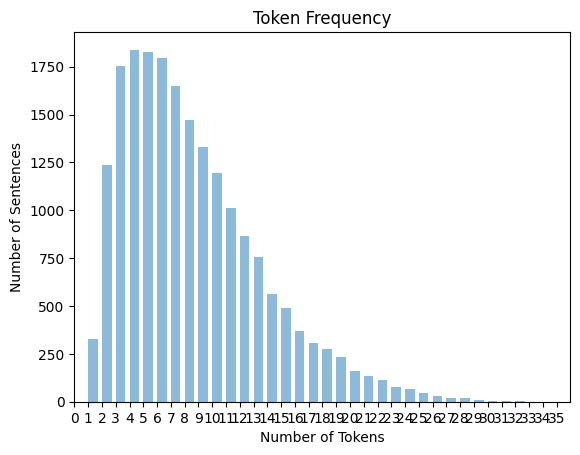

In [12]:
token_lengths = [len(t) for t in df['Tweet_lemmatized']]
plt.hist(token_lengths,bins=33,width = 0.7, fc="green",alpha=0.5)
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Sentences')
plt.title('Token Frequency')
x_Values = [i for i in range(36)]
plt.xticks(x_Values)
plt.xlim(0,36)
plt.rcParams["figure.figsize"] = (10,5)
plt.show()

## All in one (Text preprocessing)

In [13]:
def clean_text(text):
    text = remove_punct(text)
    text = tokenization(text)
    text = remove_stopwords(text)
    text = lemmatizer(text)
    return text

# 3. Feature Extraction
    1. Count Vectorizer
    2. TF-IDF (Term Frequency and Inverse Document Frequency)

## 3.1 Count Vectorizer
**CountVectorizer** is a great tool provided by the *scikit-learn* library in Python. It is used to transform a given text into a vector on the basis of the frequency (count) of each word that occurs in the entire text. This is helpful when we have multiple such texts, and we wish to convert each word in each text into vectors (for using in further text analysis).
    
Let us consider a few sample texts from a document:
    
    document 1: Time flies flies like an arrow.
    document 2: Fruit flies like a banana.

    
**CountVectorizer** creates a matrix in which each unique word is represented by a column of the matrix, and each text sample from the document is a row in the matrix. The value of each cell is nothing but the count of the word in that particular text sample.

Vocabulary:  {'time': 6, 'flies': 3, 'like': 5, 'an': 0, 'arrow': 1, 'fruit': 4, 'banana': 2}
Encoded Document is:
[[1 1 0 2 0 1 1]
 [0 0 1 1 1 1 0]]
['an', 'arrow', 'banana', 'flies', 'fruit', 'like', 'time']


<Axes: >

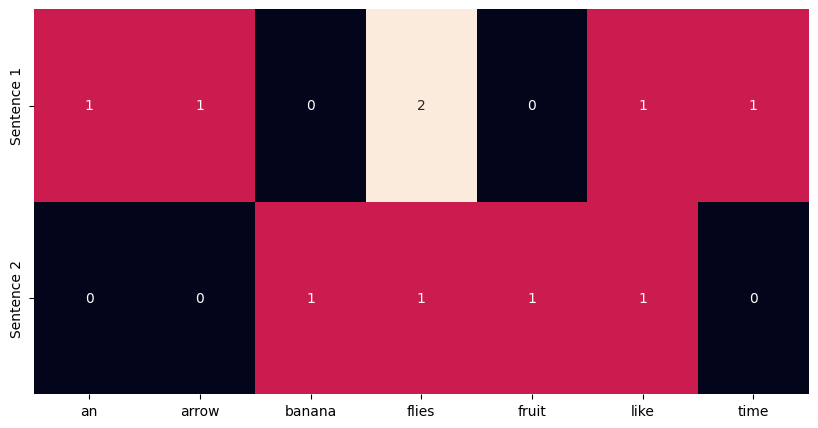

In [14]:
document = ["Time flies flies like an arrow",
            "Fruit flies like a banana"]

# Create a Vectorizer Object
vectorizer = CountVectorizer()

vectorizer.fit(document)

# Printing the identified Unique words along with their indices
print("Vocabulary: ", vectorizer.vocabulary_)

# Encode the Document
vector = vectorizer.transform(document)

# Summarizing the Encoded Texts
print("Encoded Document is:")
print(vector.toarray())

dictionary = sorted(vectorizer.vocabulary_)

print(dictionary)

sns.heatmap(vector.toarray(), annot=True, cbar=False, xticklabels=dictionary,
                                             yticklabels=['Sentence 1','Sentence 2'])

## 3.2 TF-IDF

### 3.2.1 **Term Frequency (TF)**
Term Frequent (**TF**) is a measure of how frequently a term, $t$, appears in a document, $d$:



$$TF_{t,d} = \frac{n_{t,d}}{\text{Total number of terms in document}\ d }$$



$n_{t,d}$ = Number of times term $t$ appears in a document $d$. Thus, each document and term would have its own **TF** value.

Consider these 3 documents:-

- It was the best of the time.
- it was the worst of Times.
- it is the time of stupidity.

The vocabulary or dictionary of the entire corpus would be:-

1. it
2. was
3. the
4. best
5. of
6. time
7. worst
8. is
9. stupidity

Now we will calculate the **TF** values for the **Document 3**.

Document 3 :- **it is the time of stupidity.**

- Number of words in Document 3 = **6**
- TF for the word **‘the’** = (number of times **‘the’** appears in Document 3) / (number of terms in Document 3) = **1/6**

Likewise:-

- TF(**'it'**) = 1/6
- TF(**'was'**) = 0/6 = 0
- TF(**'the'**) = 1/6
- TF(**'best'**) = 0/6 = 0
- TF(**'of'**) = 1/6
- TF(**'time'**) = 1/6
- TF(**'worst'**) = 0/6 = 0
- TF(**'is'**) = 1/6
- TF(**'stupidity'**) = 1/6

We can calculate all the term frequencies for all the terms of all the documents in this manner:-

|    Term   | Document#1 | Document#2 | Document#3 | TF (Document#1) | TF (Document#2) | TF (Document#3) |
|:---------:|:----------:|:----------:|:----------:|:---------------:|:---------------:|:---------------:|
|     it    |      1     |      1     |      1     |       1/7       |       1/6       |       1/6       |
|    was    |      1     |      1     |      0     |       1/7       |       1/6       |        0        |
|    the    |      2     |      1     |      1     |       2/7       |       1/6       |       1/6       |
|    best   |      1     |      0     |      0     |       1/7       |        0        |        0        |
|     of    |      1     |      1     |      1     |       1/7       |       1/6       |       1/6       |
|    time   |      1     |      1     |      1     |       1/7       |       1/6       |       1/6       |
|   worst   |      0     |      1     |      0     |        0        |       1/6       |        0        |
|    is     |      0     |      0     |      1     |        0        |        0        |       1/6       |
| stupidity |      0     |      0     |      1     |        0        |        0        |       1/6       |







### 3.2.2 **Inverse Document Frequency (IDF)**

IDF is a measure of how important a term is. We need the IDF value because computing just the **TF alone is not sufficient** to understand the importance of words:



$$IDF_{t} = log \ (\frac{\text{Total Number of Documents}}{\text{The Number of Documents with Term $t$}})$$



A problem with scoring word frequency is that highly frequent words **(‘is’, ‘the’, ‘a’ etc)** start to dominate in the document (e.g. larger score), but may not contain as much **“useful information”** to the model comapre to the rarer but **domain specific words**.


One approach is to rescale the frequency of words by **how often they appear in all documents**, so that the scores for frequent words like “the” that are also frequent **across all documents are penalized**.

This approach to scoring is called Term Frequency – Inverse Document Frequency, or TF-IDF for short, where:

- **Term Frequency:** is a scoring of the frequency of the word in the current document.
- **Inverse Document Frequency:** is a scoring of how rare the word is across documents.

**Thus the idf of a rare term is high, whereas the idf of a frequent term is likely to be low.**

We can calculate the IDF values for **Document 3**:

Document 3 :- **it is the time of stupidity.**

IDF(**‘it’**) =  log(total number of documents/number of documents containing the word **‘it’**) = log(3/3) = log(1) = 0

IDF(**‘stupidity’**) =  log(total number of documents/number of documents containing the word **‘stupidity’**) = log(3/1) = log(3) = 0.48

We can calculate the IDF values for each word like this. Thus, the IDF values for the entire vocabulary would be:

|    Term   | Document#1 | Document#2 | Document#3 |  IDF |
|:---------:|:----------:|:----------:|:----------:|:----:|
|     it    |      1     |      1     |      1     | 0.00 |
|    was    |      1     |      1     |      0     | 0.18 |
|    the    |      2     |      1     |      1     | 0.00 |
|    best   |      1     |      0     |      0     | 0.48 |
|     of    |      1     |      1     |      1     | 0.00 |
|    time   |      1     |      1     |      1     | 0.00 |
|   worst   |      0     |      1     |      0     | 0.48 |
|    is     |      0     |      0     |      1     | 0.48 |
| stupidity |      0     |      0     |      1     | 0.48 |

\

We can now compute the TF-IDF score for each word in the corpus. Words with a higher score are more important, and those with a lower score are less important:

$$(TF-IDF)_{t,d} = TF_{t,d} * IDF_{t}$$


You can find the overall summary in the following figure.

<div align="center">
<img src="https://drive.google.com/uc?id=1Xw5RlK_RxYtZEQtpFNaePXnJNyQmLcn1" width="680" height="230">
</div>



We can now calculate the TF-IDF score for every word in **Document 3**:

Document 3 :- **it is the time of stupidity.**

TF-IDF(‘it’, Document 3) = TF(‘it’, Document 3) * IDF(‘it’) = 1/6 * 0 = 0

Likewise:-

- TF(**'it'**) = (1/6) * 0 = 0
- TF(**'is'**) = (1/6) * 0.48 = 0.08
- TF(**'the'**) = (1/6) * 0 = 0
- TF(**'best'**) = (0/6) * 0.48 = 0
- TF(**'time'**) = (1/6) * 0 = 0
- TF(**'of'**) = (1/6) * 0 = 0
- TF(**'stupidity'**) = (1/6) * 0.48 = 0.08

Similarly, we can calculate the TF-IDF scores for all the words with respect to all the documents.

- First, notice how if there is a very common
word that occurs in all documents (i.e., n = N), IDF(w) is 0 and the TF­IDF score is 0, thereby
completely penalizing that term.
- Second, if a term occurs very rarely, perhaps in only one document,
the IDF will be the maximum possible value, log N


[[0.42519636 0.42519636 0.         0.60506143 0.         0.30253071
  0.42519636]
 [0.         0.         0.57615236 0.40993715 0.57615236 0.40993715
  0.        ]]
{'time': 6, 'flies': 3, 'like': 5, 'an': 0, 'arrow': 1, 'fruit': 4, 'banana': 2}
['an', 'arrow', 'banana', 'flies', 'fruit', 'like', 'time']


<Axes: >

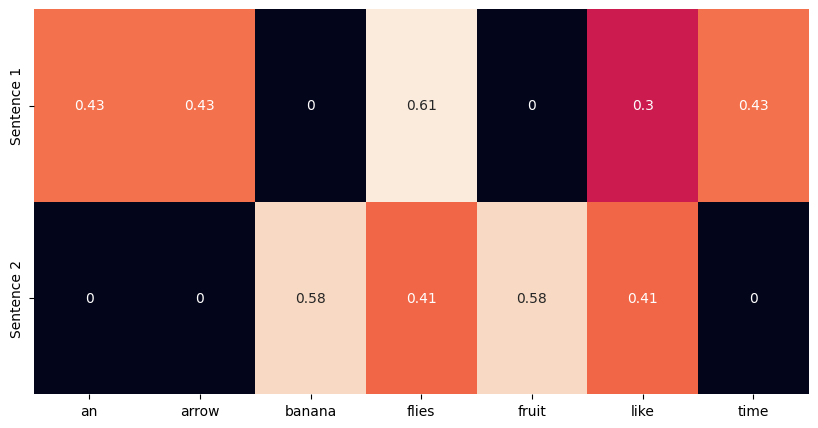

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

document = ['Time flies flies like an arrow.',
          'Fruit flies like a banana.']

tfidf_vectorizer = TfidfVectorizer()
tfidf = tfidf_vectorizer.fit_transform(document).toarray()

print (tfidf)

print (tfidf_vectorizer.vocabulary_)

dictionary = sorted(tfidf_vectorizer.vocabulary_)

print(dictionary)

sns.heatmap(tfidf, annot=True, cbar=False, xticklabels=dictionary,
                                           yticklabels=['Sentence 1','Sentence 2'])

### Applying Feature Extraction in tweet dataset

#### Train Test Split (70-30)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df['content'], df['sentiment'],test_size=0.3, random_state = 0)

In [17]:
countVectorizer1 = CountVectorizer(analyzer=clean_text)
countVector1 = countVectorizer1.fit_transform(X_train)

countVector2 = countVectorizer1.transform(X_test)

tfidf_transformer_xtrain = TfidfTransformer()
x_train = tfidf_transformer_xtrain.fit_transform(countVector1)

tfidf_transformer_xtest = TfidfTransformer()
x_test = tfidf_transformer_xtest.fit_transform(countVector2)

# 4. Models
1. Support Vector Machine (SVM)
2. Logistic Regression
3. Random Forest Classifier
4. Multinomial Naive Bayes
5. Decision Tree Classifier



**Performance Matrix :**
1.   **Accuracy** = $\frac{\text{TP+TN}}{\text{TP+TN+FP+FN}}$
2.   **Precision** = $\frac{\text{TP}}{\text{TP+FP}}$
3.   **Recall** = $\frac{\text{TP}}{\text{TP+FN}}$
4.   **F1-score** = $\frac{\text{2*Precision*Recall}}{\text{Precision+Recall}}$

## 4.1 Support Vector Machine (SVM)

In [18]:
svm = SGDClassifier()
svm.fit(x_train, y_train)

y_pred = svm.predict(x_test)

svm_acc = accuracy_score(y_pred, y_test)
svm_prec = precision_score(y_test, y_pred, average='macro')
svm_recal = recall_score(y_test, y_pred, average='macro')
svm_cm = confusion_matrix(y_test,y_pred)
svm_f1 = f1_score(y_test, y_pred, average='macro')

print('Accuracy:', '{0:.3f}'.format(svm_acc*100))
print('Precision:', '{0:.3f}'.format(svm_prec*100))
print('Recall:', '{0:.3f}'.format(svm_recal*100))
print('F1-score:', '{0:.3f}'.format(svm_f1*100))
print(classification_report(y_test,y_pred))

Accuracy: 89.583
Precision: 88.449
Recall: 83.548
F1-score: 85.693
              precision    recall  f1-score   support

       anger       0.90      0.86      0.88       828
        fear       0.88      0.84      0.86       741
         joy       0.89      0.95      0.92      2019
        love       0.84      0.76      0.80       484
     sadness       0.92      0.95      0.93      1715
    surprise       0.87      0.66      0.75       213

    accuracy                           0.90      6000
   macro avg       0.88      0.84      0.86      6000
weighted avg       0.90      0.90      0.89      6000



### 4.1.1 Confusion Matrix

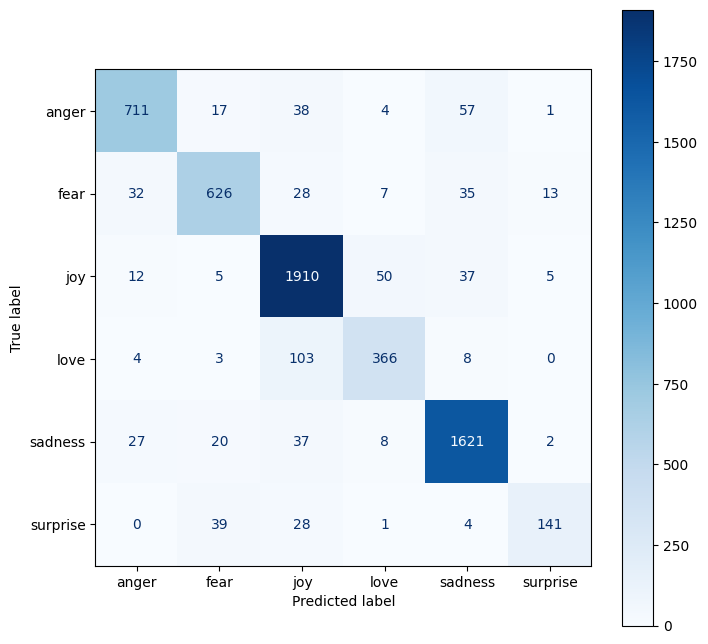

In [19]:
cm_display_svm = ConfusionMatrixDisplay(svm_cm, display_labels=svm.classes_)
fig, ax = plt.subplots(figsize=(8,8)) # adjust the size
cm_display_svm.plot(ax=ax,cmap='Blues')

## 4.2 Logistic Regression

In [20]:
logisticRegr = LogisticRegression()

logisticRegr.fit(x_train, y_train)

y_pred = logisticRegr.predict(x_test)

lr_acc = accuracy_score(y_pred, y_test)
lr_prec = precision_score(y_test, y_pred, average='macro')
lr_recal = recall_score(y_test, y_pred, average='macro')
lr_cm = confusion_matrix(y_test,y_pred)
lr_f1 = f1_score(y_test, y_pred, average='macro')

print('Accuracy:', '{0:.3f}'.format(lr_acc*100))
print('Precision:', '{0:.3f}'.format(lr_prec*100))
print('Recall:', '{0:.3f}'.format(lr_recal*100))
print('F1-score:', '{0:.3f}'.format(lr_f1*100))
print(classification_report(y_test,y_pred))

Accuracy: 86.200
Precision: 87.959
Recall: 76.543
F1-score: 80.762
              precision    recall  f1-score   support

       anger       0.91      0.78      0.84       828
        fear       0.87      0.77      0.82       741
         joy       0.82      0.95      0.88      2019
        love       0.87      0.64      0.73       484
     sadness       0.88      0.94      0.91      1715
    surprise       0.92      0.52      0.66       213

    accuracy                           0.86      6000
   macro avg       0.88      0.77      0.81      6000
weighted avg       0.87      0.86      0.86      6000



### 4.2.1 Confusion Matrix

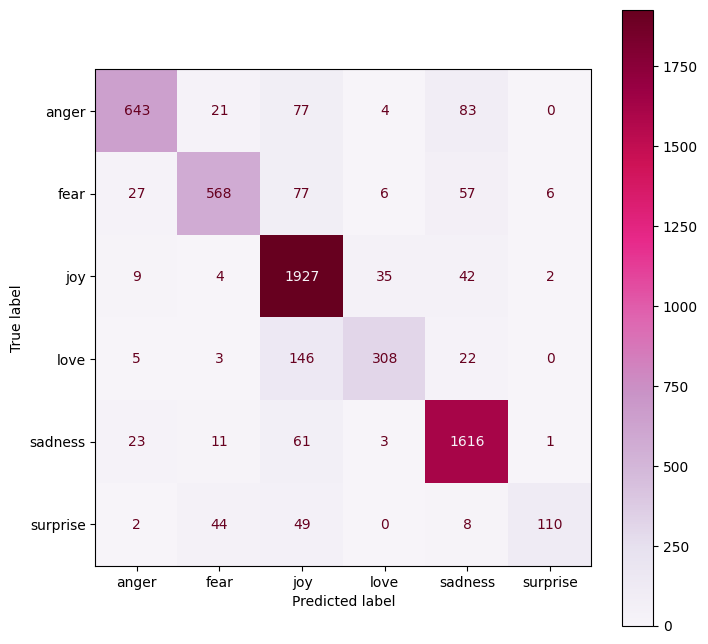

In [21]:
cm_display_lr = ConfusionMatrixDisplay(lr_cm, display_labels=logisticRegr.classes_)
fig, ax = plt.subplots(figsize=(8,8)) # adjust the size
cm_display_lr.plot(ax=ax,cmap='PuRd')

## 4.3 Random Forest Classifier

random forest builds multiple decision trees and merges them together to get a more accurate and stable prediction.

**Hyperparametes:**

**Increasing the predictive power**

Firstly, there is the **n_estimators** hyperparameter, which is just the number of trees the algorithm builds before taking the maximum voting or taking the averages of predictions. In general, a higher number of trees increases the performance and makes the predictions more stable, but it also slows down the computation.

Another important hyperparameter is **max_features**, which is the maximum number of features random forest considers to split a node. Sklearn provides several options, all described in the documentation.

The last important hyperparameter is **min_sample_leaf**. This determines the minimum number of leafs required to split an internal node.

In [22]:
rfc = RandomForestClassifier(n_estimators=1, random_state=0)

rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

rfc_acc = accuracy_score(y_pred, y_test)
rfc_prec = precision_score(y_test, y_pred, average='macro')
rfc_recal = recall_score(y_test, y_pred, average='macro')
rfc_cm = confusion_matrix(y_test,y_pred)
rfc_f1 = f1_score(y_test, y_pred, average='macro')

print('Accuracy:', '{0:.3f}'.format(rfc_acc*100))
print('Precision:', '{0:.3f}'.format(rfc_prec*100))
print('Recall:', '{0:.3f}'.format(rfc_recal*100))
print('F1-score:', '{0:.3f}'.format(rfc_f1*100))
print(classification_report(y_test,y_pred))

Accuracy: 73.533
Precision: 71.713
Recall: 67.389
F1-score: 69.107
              precision    recall  f1-score   support

       anger       0.69      0.70      0.69       828
        fear       0.74      0.74      0.74       741
         joy       0.76      0.78      0.77      2019
        love       0.73      0.52      0.60       484
     sadness       0.74      0.79      0.76      1715
    surprise       0.65      0.52      0.58       213

    accuracy                           0.74      6000
   macro avg       0.72      0.67      0.69      6000
weighted avg       0.73      0.74      0.73      6000



### 4.3.1 Confusion Matrix

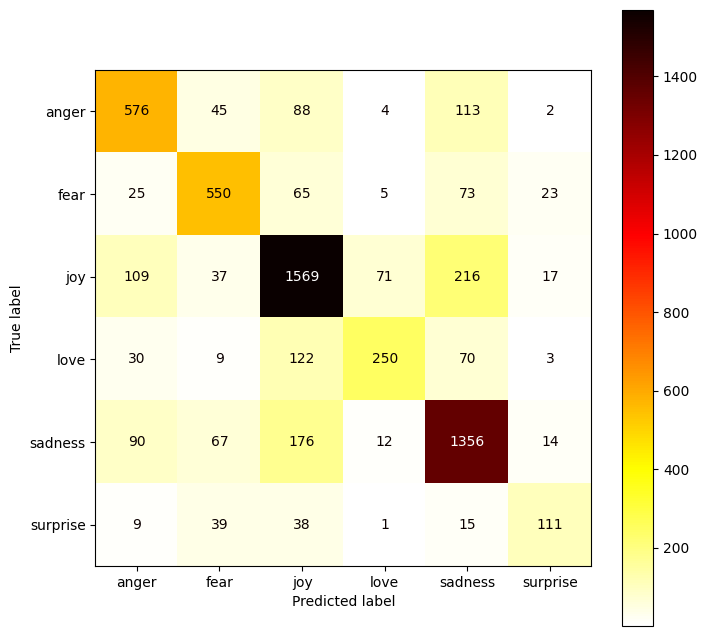

In [23]:
cm_display_rfc = ConfusionMatrixDisplay(rfc_cm, display_labels=rfc.classes_)
fig, ax = plt.subplots(figsize=(8,8)) # adjust the size
cm_display_rfc.plot(ax=ax,cmap='hot_r')

## 4.5 Multinomial Naive Bayes Classifier

In [24]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

y_pred = mnb.predict(x_test)

mnb_acc = accuracy_score(y_pred, y_test)
mnb_prec = precision_score(y_test, y_pred, average='macro')
mnb_recal = recall_score(y_test, y_pred, average='macro')
mnb_cm = confusion_matrix(y_test,y_pred)
mnb_f1 = f1_score(y_test, y_pred, average='macro')

print('Accuracy:', '{0:.3f}'.format(mnb_acc*100))
print('Precision:', '{0:.3f}'.format(mnb_prec*100))
print('Recall:', '{0:.3f}'.format(mnb_recal*100))
print('F1-score:', '{0:.3f}'.format(mnb_f1*100))
print(classification_report(y_test,y_pred))

Accuracy: 67.633
Precision: 85.613
Recall: 43.058
F1-score: 43.576
              precision    recall  f1-score   support

       anger       0.95      0.34      0.50       828
        fear       0.88      0.26      0.40       741
         joy       0.63      0.97      0.77      2019
        love       1.00      0.07      0.13       484
     sadness       0.67      0.93      0.78      1715
    surprise       1.00      0.02      0.04       213

    accuracy                           0.68      6000
   macro avg       0.86      0.43      0.44      6000
weighted avg       0.76      0.68      0.61      6000



### 4.5.1 Confusion Matrix

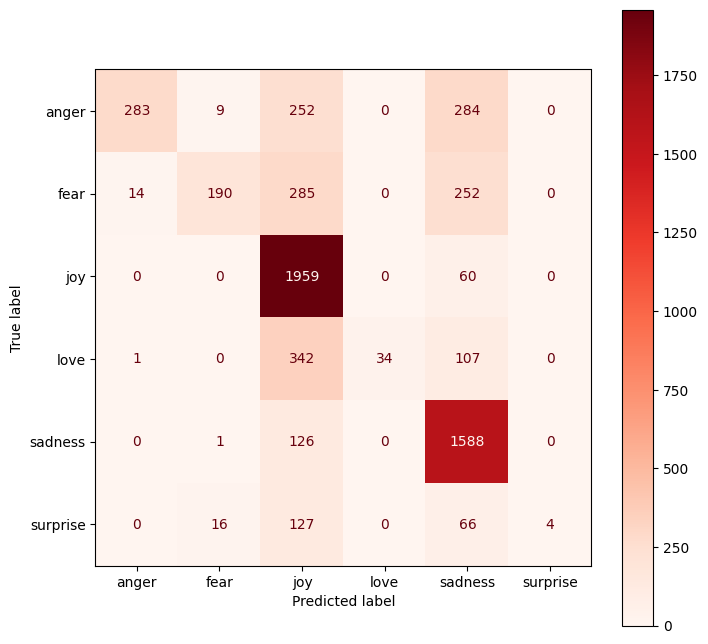

In [25]:
cm_display_mnb = ConfusionMatrixDisplay(mnb_cm, display_labels=mnb.classes_)
fig, ax = plt.subplots(figsize=(8,8)) # adjust the size
cm_display_mnb.plot(ax=ax,cmap='Reds')

## 4.6 Decision Tree Classifier

In [26]:
dt = tree.DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)


dt_acc = accuracy_score(y_pred, y_test)
dt_prec = precision_score(y_test, y_pred, average='macro')
dt_recal = recall_score(y_test, y_pred, average='macro')
dt_cm = confusion_matrix(y_test,y_pred)
dt_f1 = f1_score(y_test, y_pred, average='macro')

print('Accuracy:', '{0:.3f}'.format(dt_acc*100))
print('Precision:', '{0:.3f}'.format(dt_prec*100))
print('Recall:', '{0:.3f}'.format(dt_recal*100))
print('F1-score:', '{0:.3f}'.format(dt_f1*100))
print(classification_report(y_test,y_pred))

Accuracy: 86.700
Precision: 83.016
Recall: 84.529
F1-score: 83.715
              precision    recall  f1-score   support

       anger       0.88      0.85      0.86       828
        fear       0.82      0.85      0.84       741
         joy       0.91      0.87      0.89      2019
        love       0.76      0.82      0.78       484
     sadness       0.88      0.91      0.90      1715
    surprise       0.73      0.78      0.75       213

    accuracy                           0.87      6000
   macro avg       0.83      0.85      0.84      6000
weighted avg       0.87      0.87      0.87      6000



### 4.6.1 Confusion Matrix

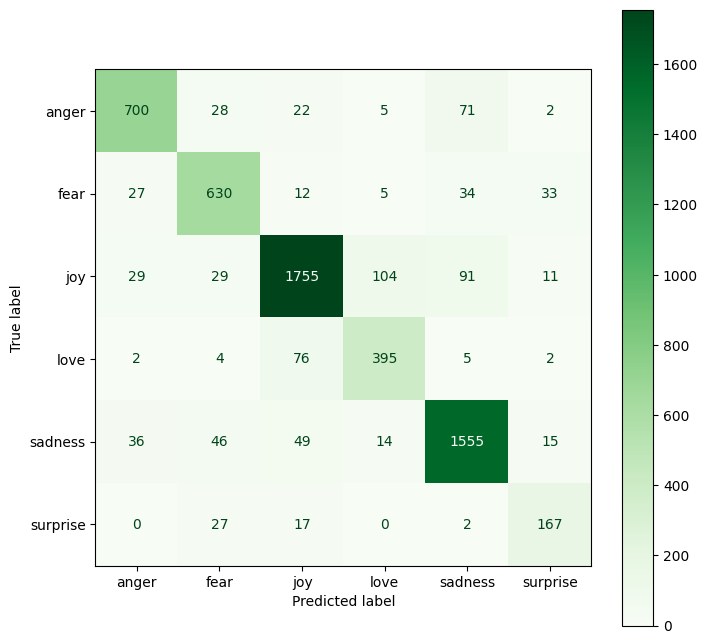

In [27]:
cm_display_dt = ConfusionMatrixDisplay(dt_cm, display_labels=dt.classes_)
fig, ax = plt.subplots(figsize=(8,8)) # adjust the size
cm_display_dt.plot(ax=ax,cmap='Greens')

# 5. Summary Visualization

In [28]:
def get_prec_recall_per_emotion(cm):
    per_emotion_precision = []
    for i in range(len(cm)):
        count_per_emotion,accurate = 0,0
        for j in range(len(cm)):
            if i == j:
                accurate = cm[j][i]
            count_per_emotion += cm[j][i]
        per_emotion_precision.append(round((accurate/count_per_emotion)*100,3))

    per_emotion_recall = []
    for i in range(len(cm)):
        count_per_emotion,accurate = 0,0
        for j in range(len(cm)):
            if i == j:
                accurate = cm[i][j]
            count_per_emotion += cm[i][j]
        per_emotion_recall.append(round((accurate/count_per_emotion)*100,3))

    return per_emotion_precision, per_emotion_recall

## 5.1 - Precision of all models

In [29]:
svm_per_prec,svm_per_recall = get_prec_recall_per_emotion(svm_cm)
lr_per_prec,lr_per_recall = get_prec_recall_per_emotion(lr_cm)
rfc_per_prec,rfc_per_recall = get_prec_recall_per_emotion(rfc_cm)
mnb_per_prec,mnb_per_recall = get_prec_recall_per_emotion(mnb_cm)
dt_per_prec,dt_per_recall = get_prec_recall_per_emotion(dt_cm)

per_precision_list = pd.DataFrame({'Support vector Machine' : svm_per_prec,
                                'Logistic Regression' : lr_per_prec,
                                'Random Forest' : rfc_per_prec,
                                'Naive Bayes' : mnb_per_prec,
                                'Decision Tree' : dt_per_prec},
                                index=svm.classes_)
per_precision_list

,Support vector Machine,Logistic Regression,Random Forest,Naive Bayes,Decision Tree
anger,90.458,90.691,68.653,94.966,88.161
fear,88.169,87.250,73.628,87.963,82.461
joy,89.086,82.456,76.239,63.378,90.886
love,83.945,86.517,72.886,100.000,75.526
sadness,91.998,88.403,73.576,67.374,88.453
surprise,87.037,92.437,65.294,100.000,72.609


## 5.2 - Recall of all models

In [30]:
per_recall_list = pd.DataFrame({'Support vector Machine' : svm_per_recall,
                                'Logistic Regression' : lr_per_recall,
                                'Random Forest' : rfc_per_recall,
                                'Naive Bayes' : mnb_per_recall,
                                'Decision Tree' : dt_per_recall},
                                index=svm.classes_)
per_recall_list

,Support vector Machine,Logistic Regression,Random Forest,Naive Bayes,Decision Tree
anger,85.870,77.657,69.565,34.179,84.541
fear,84.480,76.653,74.224,25.641,85.020
joy,94.601,95.443,77.712,97.028,86.924
love,75.620,63.636,51.653,7.025,81.612
sadness,94.519,94.227,79.067,92.595,90.671
surprise,66.197,51.643,52.113,1.878,78.404


## 5.3 Accuracy Visualization for all models

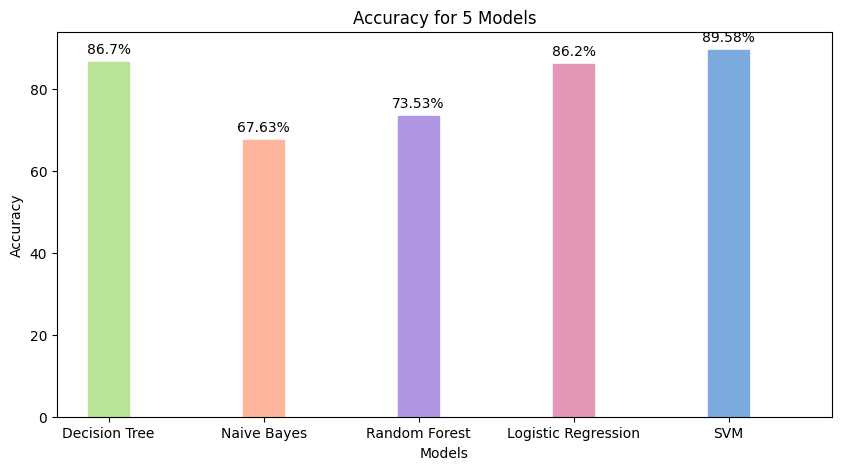

In [38]:
import matplotlib.pyplot as plt

# Sample data (ensure to define these variables)
algorithms = ['Decision Tree', 'Naive Bayes', 'Random Forest', 'Logistic Regression', 'SVM']
algorithm_acc = [dt_acc*100, mnb_acc*100, rfc_acc*100, lr_acc*100, svm_acc*100]

# Create figure
fig = plt.figure(figsize=(10, 5))

# Set bar width smaller to create space between bars
bar_width = 0.4  # Decrease bar width
x_pos = [i * 1.5 for i in range(len(algorithms))]  # Increase spacing between bars

# Create bars with adjusted width
bar_list = plt.bar(x_pos, algorithm_acc, color='blue', width=bar_width)

# Set specific colors for each bar
bar_list[4].set_color('#7CAADE')
bar_list[3].set_color('#E396B6')
bar_list[2].set_color('#B096E3')
bar_list[1].set_color('#FFB49C')
bar_list[0].set_color('#B9E396')

# Labeling
plt.xlabel('Models', color='black')
plt.ylabel('Accuracy', color='black')
plt.title('Accuracy for 5 Models')
plt.xlim(-0.5, len(algorithms) * 1.5 - 0.5)  # Adjust to center the bars and maintain space

# Set tick positions to match the bars
plt.xticks(x_pos, algorithms)

# Add text labels to the bars (accuracy values above each bar)
for i, v in enumerate(algorithm_acc):
    # Place the label slightly above the bar
    plt.text(x_pos[i], v + 2, str(round(v, 2)) + '%', color='black', fontsize=10, ha='center')

# Display plot
plt.show()

# 6. Prediction

In [39]:
while True:
    input_str = input("What's in your mind: ")
    if input_str == 'nothing':
        break

    processed_text = tfidf_transformer_xtest.fit_transform(countVectorizer1.transform([input_str]))
    print('Emotion using SVM: ',end = '')
    print(svm.predict(processed_text))
    print('Emotion using Logistic Regression: ',end = '')
    print(logisticRegr.predict(processed_text))
    print('Emotion using Decision Tree: ',end = '')
    print(dt.predict(processed_text))
    print('Emotion using Naive Bayes: ',end = '')
    print(mnb.predict(processed_text))
    print('Emotion using Random Forest: ',end = '')
    print(rfc.predict(processed_text))

KeyboardInterrupt: Interrupted by user